In [25]:
# Étape 5 : Interprétation et Visualisation

# imports
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

print("imports done")

# chargement du fichier csv
df = pd.read_csv("our_dataset.csv")

imports done


In [30]:
print(df.head())
print()
print()
print(df["Éditeur"].unique())

               ID_ANSSI                                        Titre_ANSSI  \
0  CERTFR-2026-AVI-0699           Vulnérabilité dans Cisco Catalyst SD-WAN   
1  CERTFR-2026-AVI-0711  Multiples vulnérabilités dans les VPN Check Point   
2  CERTFR-2026-AVI-0711  Multiples vulnérabilités dans les VPN Check Point   
3  CERTFR-2026-AVI-0712      Vulnérabilité dans Veeam Backup & Replication   
4  CERTFR-2026-AVI-0713  Vulnérabilité dans les produits Schneider Elec...   

   Type         Date                                         Lien_ANSSI  \
0  Avis  05 Jun 2026  https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...   
1  Avis  09 Jun 2026  https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...   
2  Avis  09 Jun 2026  https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...   
3  Avis  09 Jun 2026  https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...   
4  Avis  09 Jun 2026  https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-...   

              CVE  CVSS Base_Severity      CWE  \
0  CVE-2026-20245   7.8       

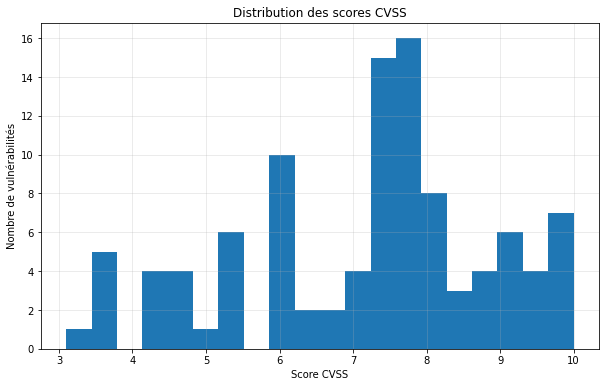

In [39]:
# Histogramme des scores CVSS
# Pour observer la distribution des vulnérabilités selon leur score.


plt.figure(figsize=(10,6))

plt.hist(df["CVSS"].dropna(), bins=20)

plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.title("Distribution des scores CVSS")

plt.grid(alpha=0.3)

plt.show()

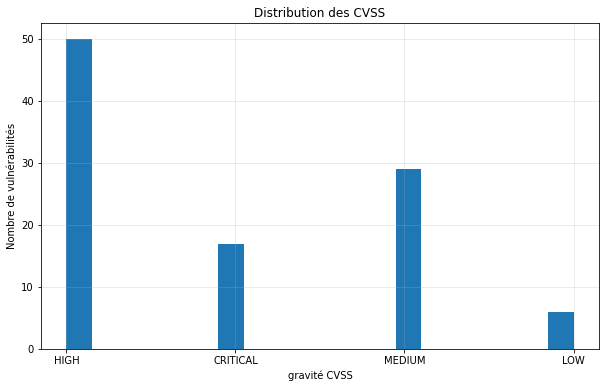

In [41]:
# Histogramme des scores CVSS
# Pour observer la distribution des vulnérabilités selon leur gravité/Base_Severity.


plt.figure(figsize=(10,6))

plt.hist(df["Base_Severity"].dropna(), bins=20)

plt.xlabel("gravité CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.title("Distribution des CVSS")

plt.grid(alpha=0.3)

plt.show()

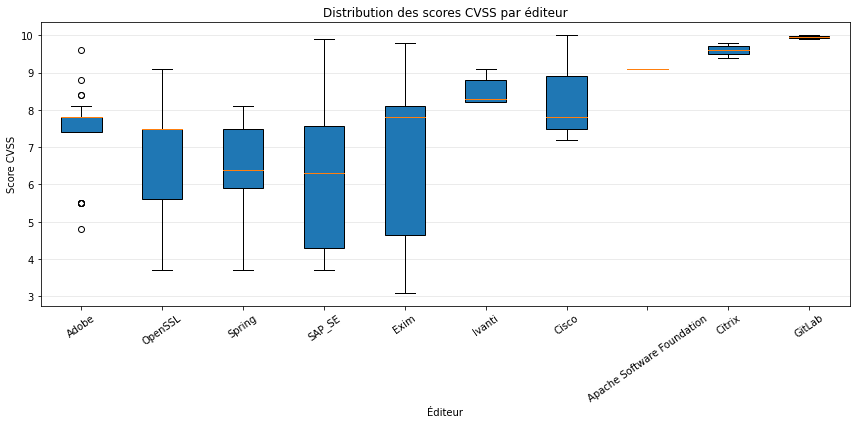

In [19]:
# Boxplot CVSS par éditeur
# Montre la dispersion des scores CVSS pour les éditeurs ayant le plus de vulnérabilités.


# Top 10 éditeurs les plus représentés
top_editors = (df["Éditeur"].value_counts().head(10).index)

df_top = df[df["Éditeur"].isin(top_editors)]

data = [
    df_top[df_top["Éditeur"] == vendor]["CVSS"].dropna()
    for vendor in top_editors
]

plt.figure(figsize=(12,6))

plt.boxplot(data, labels=top_editors, patch_artist=True)

plt.ylabel("Score CVSS")
plt.xlabel("Éditeur")
plt.title("Distribution des scores CVSS par éditeur")

plt.xticks(rotation=35)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

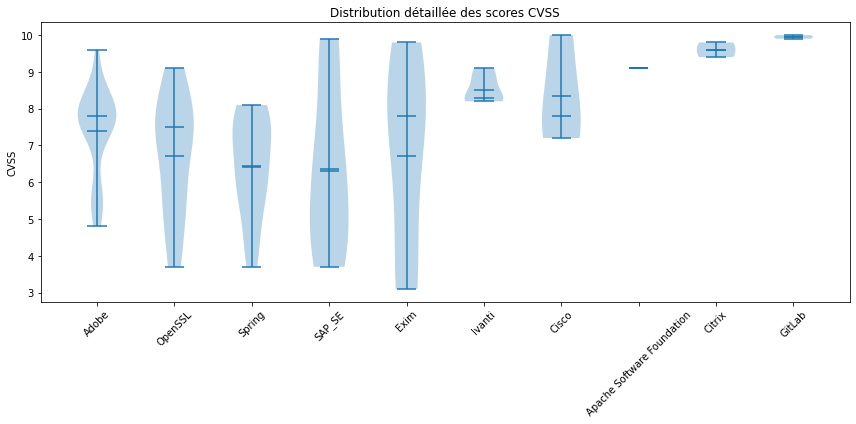

In [18]:
# Violin Plot CVSS par éditeur


top_editors = (df["Éditeur"].value_counts().head(10).index)

df_top = df[df["Éditeur"].isin(top_editors)]

data = [
    df_top[df_top["Éditeur"] == vendor]["CVSS"].dropna()
    for vendor in top_editors
]

plt.figure(figsize=(12,6))

plt.violinplot(data, showmeans=True, showmedians=True)

plt.xticks(
    range(1, len(top_editors)+1),
    top_editors,
    rotation=35
)

plt.ylabel("CVSS")
plt.title("Distribution détaillée des scores CVSS")

plt.tight_layout()
plt.show()

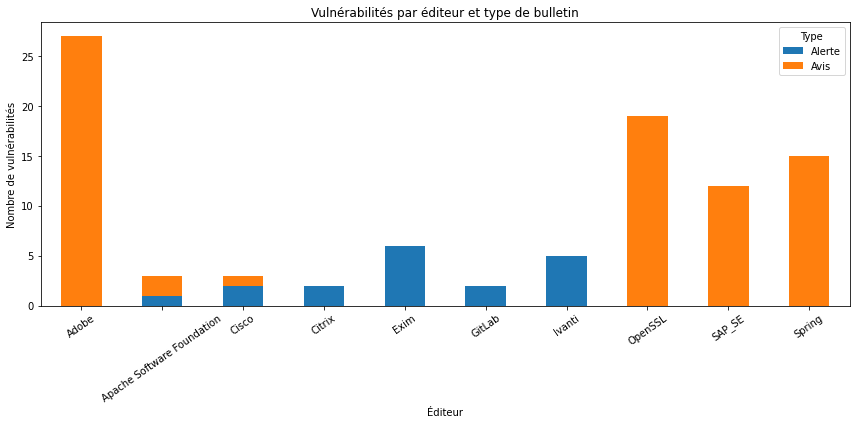

In [14]:
# Nombre de vulnérabilités par éditeur et type de bulletin
# Pour voir quels éditeurs génèrent le plus d'alertes critiques.


top_editors = (df["Éditeur"].value_counts().head(10).index)

df_top = df[df["Éditeur"].isin(top_editors)]

pivot = pd.crosstab(df_top["Éditeur"], df_top["Type"])

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Vulnérabilités par éditeur et type de bulletin")
plt.xlabel("Éditeur")
plt.ylabel("Nombre de vulnérabilités")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

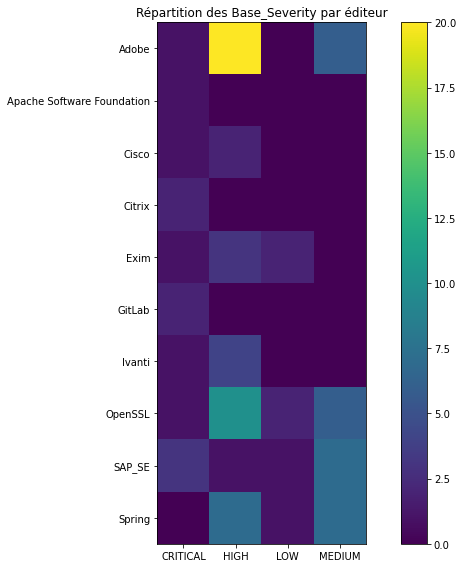

In [24]:
# Heatmap Éditeur x Base_Severity


top_editors = (df["Éditeur"].value_counts().head(10).index)

df_top = df[df["Éditeur"].isin(top_editors)]

heatmap = pd.crosstab(df_top["Éditeur"], df_top["Base_Severity"])

fig, ax = plt.subplots(figsize=(10,8))

im = ax.imshow(heatmap)

ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)

ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)

plt.colorbar(im)

plt.title("Répartition des Base_Severity par éditeur")

plt.tight_layout()
plt.show()

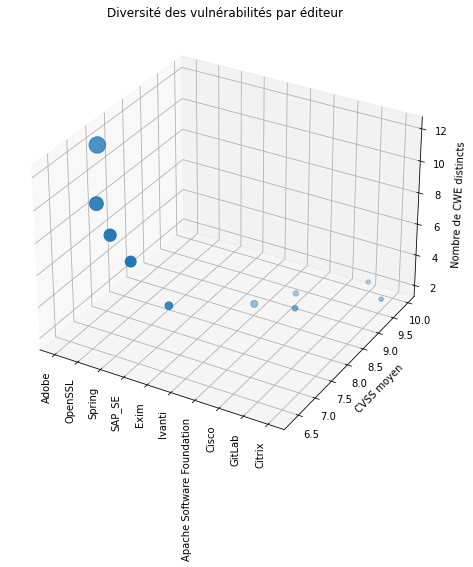

In [38]:
# Test de Graphique 3D : Éditeur x CVSS moyen x Variété CWE


# X = éditeur
# Y = CVSS moyen
# Z = nombre de CWE différents

# Pour identifier :
# les éditeurs avec beaucoup de vulnérabilités différentes ;
# ceux qui ont toujours les mêmes erreurs ;
# ceux qui combinent diversité de CWE et forte criticité.


stats = (
    df.groupby("Éditeur")
      .agg(
          cvss_mean=("CVSS","mean"),
          nb_cwe=("CWE","nunique"),
          nb_cve=("CVE","count")
      )
      .sort_values("nb_cve", ascending=False)
      .head(10)
)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    range(len(stats)),
    stats["cvss_mean"],
    stats["nb_cwe"],
    s=stats["nb_cve"]*10
)

ax.set_xticks(range(len(stats)))
ax.set_xticklabels(
    stats.index,
    rotation=90
)

ax.set_ylabel("CVSS moyen")
ax.set_zlabel("Nombre de CWE distincts")

plt.title("Diversité des vulnérabilités par éditeur")

plt.show()

/tmp/ipykernel_495/2132729786.py:56: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


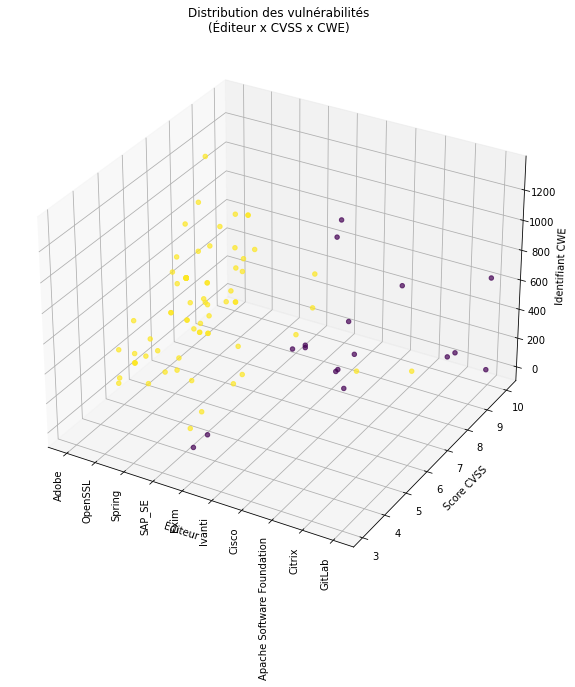

In [34]:
# Nuage de points 3D : Éditeur × CVSS × CWE

#Chaque point = une vulnérabilité.
#Axe X = éditeur
#Axe Y = score CVSS
#Axe Z = CWE
#Couleur = type de bulletin (Avis/Alerte)

#Pour voir :
#les éditeurs qui accumulent les CVE critiques ;
#les CWE dominants ;
#les regroupements intéressants.


# Encodage des catégories
top_editors = (df["Éditeur"].value_counts().head(10).index)

df_plot = df[df["Éditeur"].isin(top_editors)].copy()

df_plot["editor_id"] = pd.Categorical(
    df_plot["Éditeur"],
    categories=top_editors
).codes

df_plot["cwe_id"] = (
    df_plot["CWE"]
    .astype(str)
    .str.extract(r'(\d+)')
    .fillna(0)
    .astype(int)
)

fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_plot["editor_id"],
    df_plot["CVSS"],
    df_plot["cwe_id"],
    c=pd.Categorical(df_plot["Type"]).codes,
    alpha=0.7
)

ax.set_xlabel("Éditeur")
ax.set_ylabel("Score CVSS")
ax.set_zlabel("Identifiant CWE")

ax.set_xticks(range(len(top_editors)))
ax.set_xticklabels(top_editors, rotation=90)

plt.title(
    "Distribution des vulnérabilités\n"
    "(Éditeur x CVSS x CWE)"
)

plt.tight_layout()
plt.show()

In [37]:
#
